In [1]:
# Практический блок 2.1. Создание окружения
# Проверка окружения
import sys
import pandas as pd
import numpy as np
import matplotlib

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)


Python: 3.13.5
pandas: 3.0.5
NumPy: 2.5.2
Matplotlib: 3.11.1


In [2]:
# Практический блок 3.1. Векторное преобразование
import numpy as np

wind_ms = np.array([1.14, 0.80, 0.97])
wind_kmh = wind_ms * 3.6
print(np.round(wind_kmh, 2))


[4.1  2.88 3.49]


In [3]:
# Практический блок 3.2. Ключевые объекты Pandas
s = pd.Series([10, 20, 30], name="value")
frame = pd.DataFrame({
    "type": ["A", "B", "A"],
    "value": [10, 20, 30]
})

print(type(s).__name__)
print(type(frame).__name__)
print(frame.groupby("type")["value"].sum())


Series
DataFrame
type
A    40
B    20
Name: value, dtype: int64


In [4]:
# Практический блок 4.1. Загрузка FiresRu.csv
from pathlib import Path
import pandas as pd

DATA_PATH = Path("FiresRu.csv")
df = pd.read_csv(DATA_PATH)

print(df.shape)
print(df.columns.tolist())
df.head()


(26681, 9)
['type_name', 'type_id', 'lon', 'lat', 'temperature_c', 'precipitation_mm', 'relative_humidity', 'wind_speed_ms', 'solar_radiation']


,type_name,type_id,lon,lat,temperature_c,precipitation_mm,relative_humidity,wind_speed_ms,solar_radiation
0,Natural fire,4,131.5866,47.8662,-9.44,0.01,72.98,1.14,4.59
1,Natural fire,4,131.5885,47.8809,-9.44,0.01,72.98,1.14,4.59
2,Forest fire,3,131.9871,48.4973,-10.71,0.05,81.31,0.80,4.24
3,Natural fire,4,131.9031,43.6277,-7.77,0.00,68.41,0.97,4.66
4,Natural fire,4,131.5706,47.8581,-9.44,0.01,72.98,1.14,4.59


In [5]:
# Практический блок 5.1. Структура и память
import io

buf = io.StringIO()
df.info(buf=buf, memory_usage="deep")
print(buf.getvalue())


<class 'pandas.DataFrame'>
RangeIndex: 26681 entries, 0 to 26680
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   type_name          26681 non-null  str    
 1   type_id            26681 non-null  int64  
 2   lon                26681 non-null  float64
 3   lat                26681 non-null  float64
 4   temperature_c      26681 non-null  float64
 5   precipitation_mm   26681 non-null  float64
 6   relative_humidity  26681 non-null  float64
 7   wind_speed_ms      26681 non-null  float64
 8   solar_radiation    26681 non-null  float64
dtypes: float64(7), int64(1), str(1)
memory usage: 2.1 MB



In [6]:
# Практический блок 5.2. Пропуски, дубликаты и уникальные значения
print("Пропуски по столбцам:")
print(df.isna().sum())
print("Полных дубликатов:", df.duplicated().sum())
print("Число уникальных значений:")
print(df.nunique())


Пропуски по столбцам:
type_name            0
type_id              0
lon                  0
lat                  0
temperature_c        0
precipitation_mm     0
relative_humidity    0
wind_speed_ms        0
solar_radiation      0
dtype: int64
Полных дубликатов: 0
Число уникальных значений:
type_name                5
type_id                  5
lon                  25708
lat                  23547
temperature_c         2581
precipitation_mm       571
relative_humidity     4028
wind_speed_ms          532
solar_radiation        731
dtype: int64


In [7]:
# Практический блок 5.3. Проверка соответствия кода и категории
type_map = (
    df[["type_id", "type_name"]]
    .drop_duplicates()
    .sort_values("type_id")
)
print(type_map.to_string(index=False))


 type_id         type_name
       1 Uncontrolled burn
       2         Peat fire
       3       Forest fire
       4      Natural fire
       5   Controlled burn


In [8]:
# Практический блок 5.4. Описательная статистика
cols = [
    "lon", "lat", "temperature_c", "precipitation_mm",
    "relative_humidity", "wind_speed_ms", "solar_radiation"
]
print(df[cols].describe().round(2).T)


                     count    mean    std    min    25%    50%     75%     max
lon                26681.0  106.35  27.31  20.37  82.41  96.56  133.90  175.87
lat                26681.0   57.53   4.30  41.71  53.95  58.97   60.64   70.33
temperature_c      26681.0   17.89   5.68 -34.88  15.70  19.08   21.39   31.94
precipitation_mm   26681.0    0.46   1.46   0.00   0.00   0.04    0.30   25.85
relative_humidity  26681.0   69.44  11.43  24.70  62.93  71.35   77.91   99.83
wind_speed_ms      26681.0    0.63   0.93   0.00   0.11   0.25    0.66    7.42
solar_radiation    26681.0    5.57   1.50   0.42   4.55   5.68    6.71    8.97


In [9]:
# Практический блок 6.1. Оптимизация типов
before = df.memory_usage(deep=True).sum()

clean_df = df.copy()
clean_df["type_name"] = clean_df["type_name"].astype("category")
clean_df["type_id"] = clean_df["type_id"].astype("int8")

after = clean_df.memory_usage(deep=True).sum()
print(f"До: {before / 1024**2:.2f} MiB")
print(f"После: {after / 1024**2:.2f} MiB")
print(f"Снижение: {(1 - after / before) * 100:.1f}%")


До: 2.13 MiB
После: 1.48 MiB
Снижение: 30.8%


In [10]:
# Практический блок 6.2. Создание вычисляемых признаков
clean_df["wind_speed_kmh"] = (
        clean_df["wind_speed_ms"] * 3.6
).round(2)

clean_df["is_forest_fire"] = (
        clean_df["type_name"] == "Forest fire"
)

print(clean_df[
          ["type_name", "wind_speed_ms", "wind_speed_kmh",
           "is_forest_fire"]
      ].head())

      type_name  wind_speed_ms  wind_speed_kmh  is_forest_fire
0  Natural fire           1.14            4.10           False
1  Natural fire           1.14            4.10           False
2   Forest fire           0.80            2.88            True
3  Natural fire           0.97            3.49           False
4  Natural fire           1.14            4.10           False


In [11]:
# Практический блок 7.1. Распределение наблюдений по типам
type_stats = (
    df["type_name"]
    .value_counts()
    .to_frame("n")
    .assign(share_pct=lambda x: x["n"] / len(df) * 100)
)
print(type_stats.round(2))


                       n  share_pct
type_name                          
Forest fire        18415      69.02
Natural fire        5195      19.47
Uncontrolled burn   2711      10.16
Controlled burn      333       1.25
Peat fire             27       0.10


In [12]:
# Практический блок 7.2. Групповые средние
group_stats = (
    df.groupby("type_name", observed=True)
    .agg(
        n=("type_name", "size"),
        temp_mean=("temperature_c", "mean"),
        precip_mean=("precipitation_mm", "mean"),
        humidity_mean=("relative_humidity", "mean"),
        wind_mean=("wind_speed_ms", "mean"),
        solar_mean=("solar_radiation", "mean")
    )
    .sort_values("n", ascending=False)
)
print(group_stats.round(2))


                       n  temp_mean  precip_mean  humidity_mean  wind_mean  \
type_name                                                                    
Forest fire        18415      18.69         0.50          70.30       0.42   
Natural fire        5195      17.42         0.40          69.07       0.80   
Uncontrolled burn   2711      14.21         0.29          64.35       1.64   
Controlled burn      333      10.78         0.25          69.46       1.46   
Peat fire             27      18.17         0.55          65.47       1.19   

                   solar_mean  
type_name                      
Forest fire              5.87  
Natural fire             5.14  
Uncontrolled burn        4.57  
Controlled burn          4.27  
Peat fire                5.26  


In [13]:
# Практический блок 7.3. Условная фильтрация
subset = df.loc[
    (df["relative_humidity"] < 40) &
    (df["wind_speed_ms"] > 2),
    ["type_name", "lon", "lat", "temperature_c",
     "relative_humidity", "wind_speed_ms"]
]

print("Строк в срезе:", len(subset))
print(subset.head())


Строк в срезе: 337
       type_name       lon      lat  temperature_c  relative_humidity  \
295  Forest fire   91.3929  51.0574          15.15              27.97   
478  Forest fire  104.5843  50.3723          14.67              37.89   
479  Forest fire  104.4937  50.3592          14.67              37.89   
480  Forest fire  104.4187  50.3302          14.67              37.89   
481  Forest fire  104.3001  50.3377          14.67              37.89   

     wind_speed_ms  
295           2.55  
478           2.64  
479           2.64  
480           2.64  
481           2.64  


In [14]:
# Практический блок 8.1. Корреляционная матрица
weather = [
    "temperature_c", "precipitation_mm", "relative_humidity",
    "wind_speed_ms", "solar_radiation"
]

corr = df[weather].corr()
print(corr.round(3))


                   temperature_c  precipitation_mm  relative_humidity  \
temperature_c              1.000             0.003             -0.155   
precipitation_mm           0.003             1.000              0.232   
relative_humidity         -0.155             0.232              1.000   
wind_speed_ms             -0.297            -0.047             -0.280   
solar_radiation            0.221            -0.192             -0.234   

                   wind_speed_ms  solar_radiation  
temperature_c             -0.297            0.221  
precipitation_mm          -0.047           -0.192  
relative_humidity         -0.280           -0.234  
wind_speed_ms              1.000           -0.189  
solar_radiation           -0.189            1.000  


In [15]:
# Практический блок 8.2. Правило IQR на примере скорости ветра
q1 = df["wind_speed_ms"].quantile(0.25)
q3 = df["wind_speed_ms"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

mask = (
        (df["wind_speed_ms"] < lower) |
        (df["wind_speed_ms"] > upper)
)

print(f"Q1={q1:.3f}; Q3={q3:.3f}; IQR={iqr:.3f}")
print(f"Границы: [{lower:.3f}; {upper:.3f}]")
print("Кандидатов:", mask.sum())


Q1=0.110; Q3=0.660; IQR=0.550
Границы: [-0.715; 1.485]
Кандидатов: 3652


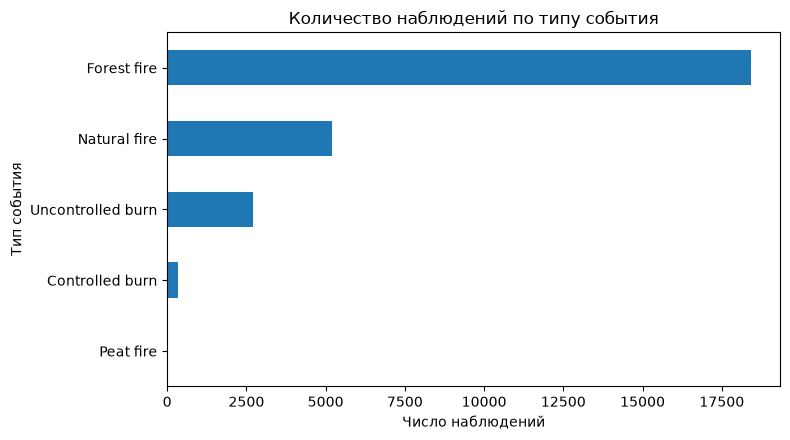

In [16]:
# Практический блок 9.1. Bar chart частоты типов событий
import matplotlib.pyplot as plt

counts = df["type_name"].value_counts().sort_values()
ax = counts.plot(kind="barh", figsize=(8, 4.5))
ax.set_title("Количество наблюдений по типу события")
ax.set_xlabel("Число наблюдений")
ax.set_ylabel("Тип события")
plt.tight_layout()
plt.show()


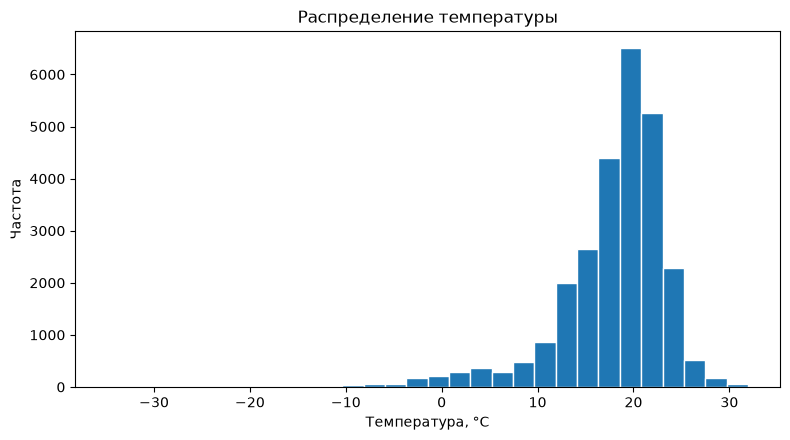

In [17]:
# Практический блок 9.2. Histogram: распределение температуры
plt.figure(figsize=(8, 4.5))
plt.hist(df["temperature_c"], bins=30, edgecolor="white")
plt.title("Распределение температуры")
plt.xlabel("Температура, °C")
plt.ylabel("Частота")
plt.tight_layout()
plt.show()


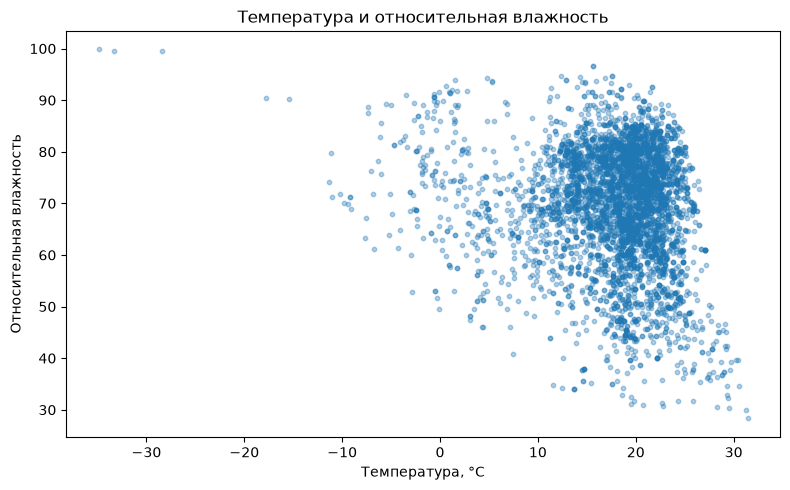

In [18]:
# Практический блок 9.3. Scatter plot для температуры и влажности
sample = df.sample(n=5000, random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(
    sample["temperature_c"],
    sample["relative_humidity"],
    s=10,
    alpha=0.35
)
plt.title("Температура и относительная влажность")
plt.xlabel("Температура, °C")
plt.ylabel("Относительная влажность")
plt.tight_layout()
plt.show()


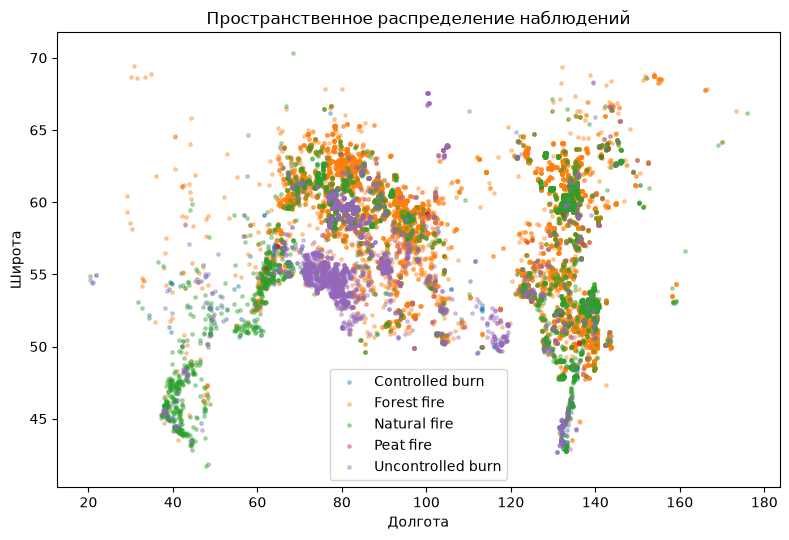

In [19]:
# Практический блок 9.4. Пространственный scatter plot
plt.figure(figsize=(8, 5.5))
for name, part in df.groupby("type_name"):
    plt.scatter(
        part["lon"], part["lat"],
        s=6, alpha=0.35, label=name
    )

plt.xlabel("Долгота")
plt.ylabel("Широта")
plt.title("Пространственное распределение наблюдений")
plt.legend()
plt.tight_layout()
plt.show()


In [20]:
# Практический блок 10.1. Сохранение подготовленного DataFrame
from pathlib import Path

OUT = Path("output")
OUT.mkdir(exist_ok=True)

clean_df.to_csv(
    OUT / "FiresRu_clean.csv",
    index=False,
    encoding="utf-8"
)

clean_df.to_json(
    OUT / "FiresRu_clean.json",
    orient="records",
    lines=True,
    force_ascii=False
)

clean_df.to_parquet(
    OUT / "FiresRu_clean.parquet",
    index=False,
    engine="pyarrow",
    compression="snappy"
)

# Изменение размеров
files = [
    OUT / "FiresRu_clean.csv",
    OUT / "FiresRu_clean.json",
    OUT / "FiresRu_clean.parquet"
]
for path in files:
    size_mib = path.stat().st_size / 1024**2
    print(f"{path.name:24s} {size_mib:7.2f} MiB")


FiresRu_clean.csv           1.74 MiB
FiresRu_clean.json          5.81 MiB
FiresRu_clean.parquet       0.61 MiB


In [21]:
# Практический блок 10.2. Проверка round-trip
csv_back = pd.read_csv(OUT / "FiresRu_clean.csv")
parquet_back = pd.read_parquet(OUT / "FiresRu_clean.parquet")

print(csv_back.shape)
print(parquet_back.shape)
print(parquet_back.dtypes)


(26681, 11)
(26681, 11)
type_name            category
type_id                  int8
lon                   float64
lat                   float64
temperature_c         float64
precipitation_mm      float64
relative_humidity     float64
wind_speed_ms         float64
solar_radiation       float64
wind_speed_kmh        float64
is_forest_fire           bool
dtype: object
